In [1]:
# Upload Dataset
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [2]:
#Load Dataset
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
#Understand Data
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [4]:
#Select Important Features
data = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [5]:
#Normalize Data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

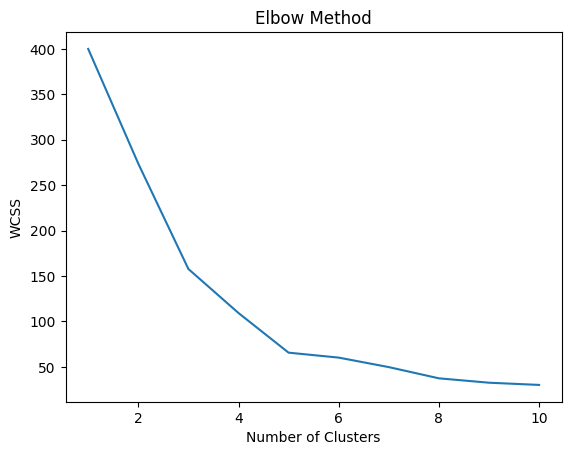

In [6]:
#Find Best K (Elbow Method)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [7]:
#Apply K-Means
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

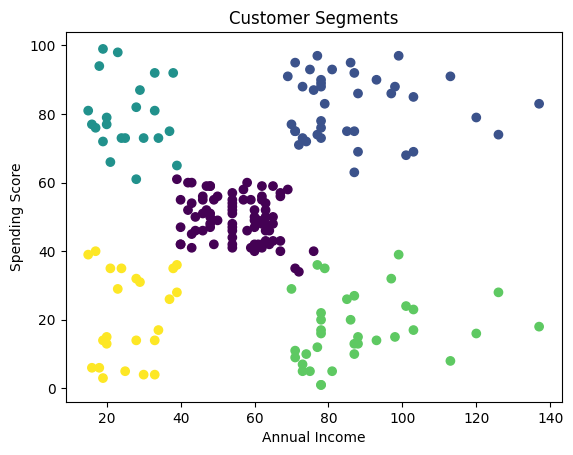

In [8]:
#Visualize Clusters
plt.scatter(data.iloc[:,0], data.iloc[:,1], c=df['Cluster'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

In [9]:
#Evaluate Model
from sklearn.metrics import silhouette_score
score = silhouette_score(scaled_data, df['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


**Customer Segmentation Insights**


*   Cluster 0 represents high-value customers with both high income and spending behavior. These customers should be targeted with premium services and loyalty rewards.
*   Cluster 1 includes customers with high income but low spending, indicating an opportunity to increase engagement through targeted promotions.

*  Cluster 2 consists of budget-conscious customers who spend relatively more despite lower income, making them suitable for discount-based marketing.
*   Cluster 3 represents low engagement customers with low income and spending, requiring reactivation strategies.

*   Cluster 4 includes average customers with moderate spending patterns, suitable for regular engagement campaigns.







In [10]:
df.to_csv("customer_segmentation_output.csv", index=False)

In [11]:
from google.colab import files
files.download("customer_segmentation_output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>